# **Plotting ENSO GDR**

Outputs: 

 - Figure: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/GDR_all_eruptions.png

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D


# FONT
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]


# PATHS (CSV inputs)

# Input tables
TABLE_DIR = "/home/563/ft3359/FT-Honours/Honours_Paper/GDR/All_Eruptions"
MODEL_CSV = os.path.join(TABLE_DIR, "ENSO-GDR-Models.csv")
RECON_CSV = os.path.join(TABLE_DIR, "ENSO-GDR-Reconstructions.csv")

# Output directory
FIG_OUT = "/home/563/ft3359/FT-Honours/Honours_Paper/Figures/GDR_all_eruptions.png"


# SETTINGS
CASE_ORDER = ["Unconditional", "El Niño", "Neutral", "La Niña"]
POOL_SPREAD = "iqr"   # "iqr" or "sd"
MIN_N_FOR_POOL = 1
SIG_LEVEL = 0.05

# COLOURS
MODEL_COLOR = "#0072B2"
RECON_COLOR = "#D55E00"

In [5]:
# HELPERS

def load_df(path: str, label: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")

    df = pd.read_csv(path)

    # Normalise column names
    if "case" in df.columns and "case_simple" not in df.columns:
        df = df.rename(columns={"case": "case_simple"})

    needed = {"dataset", "case_simple", "N_events", "r_yr1", "tau_yr", "p_value"}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"{label} CSV missing columns: {missing}\nFound: {list(df.columns)}")

    df = df.copy()
    df["dataset"] = df["dataset"].astype(str)
    df["case_simple"] = df["case_simple"].astype(str)

    # Normalise phase labels
    df["case_simple"] = df["case_simple"].str.replace(
        r"^Phase-conditioned:\s*", "", regex=True
    )

    for c in ["N_events", "r_yr1", "tau_yr", "p_value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df[df["case_simple"].isin(CASE_ORDER)].copy()
    df["case_simple"] = pd.Categorical(df["case_simple"], categories=CASE_ORDER, ordered=True)
    return df


def wlp_pool(df: pd.DataFrame, value_col: str) -> pd.DataFrame:

    rows = []
    for case in CASE_ORDER:
        sub = df[df["case_simple"] == case].copy()
        vals = sub[value_col].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        n = int(vals.size)

        if n < MIN_N_FOR_POOL:
            rows.append({
                "case_simple": case,
                "pooled_mean": np.nan,
                "pooled_q25":  np.nan,
                "pooled_q50":  np.nan,
                "pooled_q75":  np.nan,
                "pooled_sd":   np.nan,
                "n_used":      n
            })
            continue

        q25, q50, q75 = np.percentile(vals, [25, 50, 75])
        rows.append({
            "case_simple": case,
            "pooled_mean": float(q50),
            "pooled_q25":  float(q25),
            "pooled_q50":  float(q50),
            "pooled_q75":  float(q75),
            "pooled_sd":   float(np.std(vals, ddof=1)) if n >= 2 else 0.0,
            "n_used":      n
        })

    out = pd.DataFrame(rows)
    out["case_simple"] = pd.Categorical(out["case_simple"], categories=CASE_ORDER, ordered=True)
    return out.sort_values("case_simple").reset_index(drop=True)


def spread_to_err(pool_df: pd.DataFrame):

    m = pool_df["pooled_mean"].to_numpy(float)

    if POOL_SPREAD.lower() == "sd":
        sd = pool_df["pooled_sd"].to_numpy(float)
        lo = np.where(np.isfinite(sd), sd, np.nan)
        hi = np.where(np.isfinite(sd), sd, np.nan)
    else:
        q25 = pool_df["pooled_q25"].to_numpy(float)
        q75 = pool_df["pooled_q75"].to_numpy(float)
        lo = m - q25
        hi = q75 - m

    lo = np.where(np.isfinite(lo), np.maximum(lo, 0.0), np.nan)
    hi = np.where(np.isfinite(hi), np.maximum(hi, 0.0), np.nan)
    return lo, hi


def jitter(x, n, width=0.06, seed=0):
    rng = np.random.default_rng(seed)
    return x + rng.uniform(-width, width, size=n)


def print_significance_summary(title, df):
    print(f"\n{title} — significant results (p < {SIG_LEVEL})")
    for case in CASE_ORDER:
        sub = df[df["case_simple"] == case].copy()
        sig = sub[sub["p_value"] < SIG_LEVEL]
        valid = sub["p_value"].notna().sum()
        print(f"  {case} ({len(sig)} of {valid} valid):")
        if sig.empty:
            print(f"    none")
        else:
            for _, row in sig.iterrows():
                print(f"    {row['dataset']:45s}  r={row['r_yr1']:.3f}  p={row['p_value']:.4f}")


MODELS — significant results (p < 0.05)
  Unconditional (1 of 9 valid):
    IPSL-CM5A-LR                                   r=-1.437  p=0.0425
  El Niño (0 of 7 valid):
    none
  Neutral (0 of 9 valid):
    none
  La Niña (0 of 4 valid):
    none

RECONS — significant results (p < 0.05)
  Unconditional (0 of 9 valid):
    none
  El Niño (0 of 7 valid):
    none
  Neutral (0 of 9 valid):
    none
  La Niña (0 of 8 valid):
    none
Saved: /home/563/ft3359/FT-Honours/Honours_Paper/Figures/GDR_all_eruptions.png


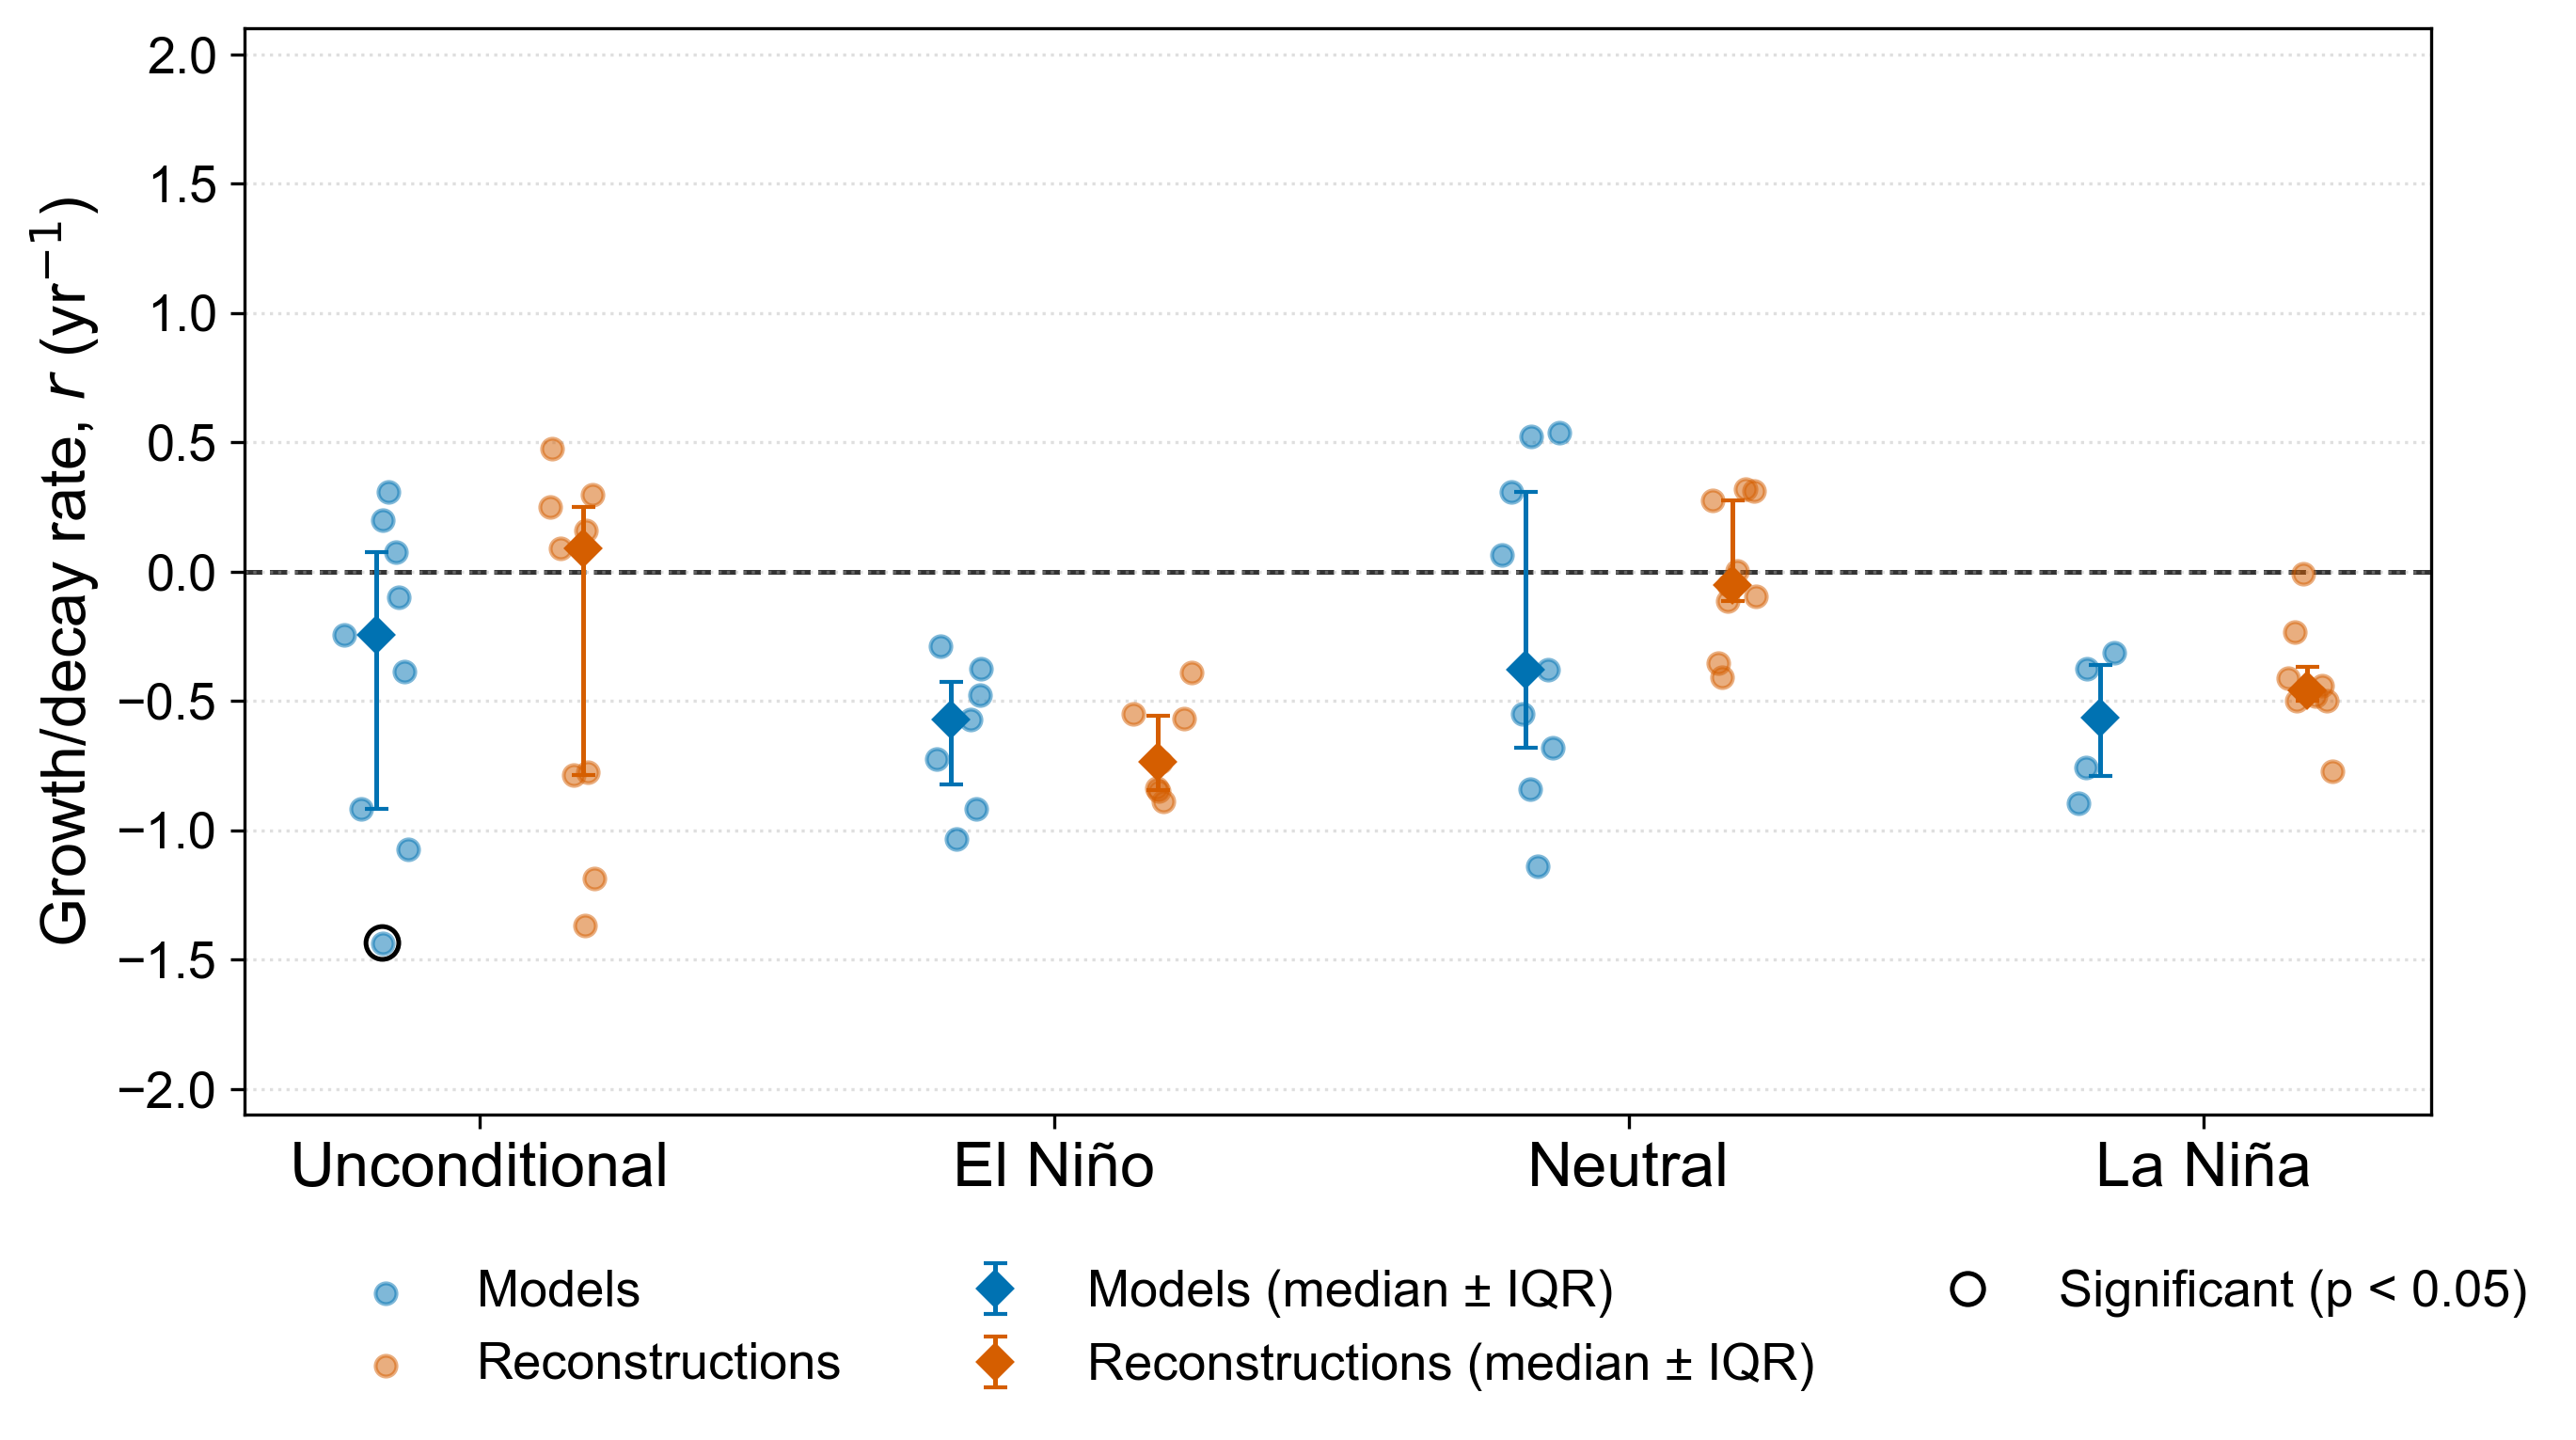

In [6]:
# LOAD DATA

df_m = load_df(MODEL_CSV, "MODELS")
df_r = load_df(RECON_CSV, "RECONS")

pool_m_r = wlp_pool(df_m, "r_yr1")
pool_r_r = wlp_pool(df_r, "r_yr1")

print_significance_summary("MODELS", df_m)
print_significance_summary("RECONS", df_r)


# PLOT
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)
x = np.arange(len(CASE_ORDER))

# scatter per dataset + significance rings
for i, case in enumerate(CASE_ORDER):
    subm = df_m[df_m["case_simple"] == case].copy()
    subr = df_r[df_r["case_simple"] == case].copy()

    xm  = jitter(np.full(len(subm), i - 0.18), len(subm), seed=100 + i)
    xr_ = jitter(np.full(len(subr), i + 0.18), len(subr), seed=200 + i)

    # Base points
    ax.scatter(
        xm, subm["r_yr1"],
        s=28, alpha=0.5,
        color=MODEL_COLOR,
        label="Models" if i == 0 else None,
        zorder=2
    )
    ax.scatter(
        xr_, subr["r_yr1"],
        s=28, alpha=0.5,
        color=RECON_COLOR,
        label="Reconstructions" if i == 0 else None,
        zorder=2
    )

    # Significant points: black ring overlay
    sigm = subm["p_value"] < SIG_LEVEL
    sigr = subr["p_value"] < SIG_LEVEL

    if sigm.any():
        ax.scatter(
            xm[sigm.to_numpy()], subm.loc[sigm, "r_yr1"],
            s=70, facecolors="none", edgecolors="black",
            linewidths=1.2, zorder=4
        )

    if sigr.any():
        ax.scatter(
            xr_[sigr.to_numpy()], subr.loc[sigr, "r_yr1"],
            s=70, facecolors="none", edgecolors="black",
            linewidths=1.2, zorder=4
        )

# pooled WLP medians + spread bars
m_lo, m_hi = spread_to_err(pool_m_r)
r_lo, r_hi = spread_to_err(pool_r_r)

ax.errorbar(
    x - 0.18, pool_m_r["pooled_mean"], yerr=[m_lo, m_hi],
    fmt="D", capsize=3, elinewidth=1.2, markersize=6,
    color=MODEL_COLOR,
    label="Models (median ± IQR)",
    zorder=5
)
ax.errorbar(
    x + 0.18, pool_r_r["pooled_mean"], yerr=[r_lo, r_hi],
    fmt="D", capsize=3, elinewidth=1.2, markersize=6,
    color=RECON_COLOR,
    label="Reconstructions (median ± IQR)",
    zorder=5
)

ax.axhline(0, linewidth=1.2, color="black", linestyle="--", alpha=0.8, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(CASE_ORDER, fontsize=16)
ax.set_ylabel("Growth/decay rate, $r$ (yr$^{-1}$)", fontsize=16)

ax.tick_params(axis="y", labelsize=13)
ax.set_ylim(-2.1, 2.1)
ax.grid(axis="y", linestyle=":", alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
sig_handle = Line2D(
    [0], [0],
    marker="o", linestyle="None",
    markerfacecolor="none", markeredgecolor="black",
    markeredgewidth=1.2, markersize=8,
    label=f"Significant (p < {SIG_LEVEL})"
)

handles.append(sig_handle)

ax.legend(
    handles, labels + [sig_handle.get_label()],
    loc="upper left", bbox_to_anchor=(0.02, -0.10),
    ncols=3, fontsize=13, frameon=False
)

os.makedirs(os.path.dirname(FIG_OUT), exist_ok=True)
fig.savefig(FIG_OUT, dpi=300, bbox_inches="tight")
print("Saved:", FIG_OUT)

plt.show()